# Recommendation System

In [23]:
# IMPORT LIBRARIES

# Data manipulation & visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn. ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.neighbors import NearestNeighbors
import warnings

import warnings
warnings.filterwarnings('ignore')

In [24]:
# LOADING ORIGINAL DATA
data = "https://breathecode.herokuapp.com/asset/internal-link?id=2326&path=adult-census-income.csv"
df = pd.read_csv(data)
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 1. Exploratory Data Analysis

In [45]:
#Dataset dimension
rows, column = df.shape
print("DATASET Dimension:")
print(f'{rows} rows and {column} columns')

DATASET Dimension:
32537 rows and 15 columns


In [46]:
# Get information about range index, number of columns and labels, data types, and the number of cells in each column (non-null values)
print("DATASET General Info:")
df.info()

DATASET General Info:
<class 'pandas.core.frame.DataFrame'>
Index: 32537 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32537 non-null  int64 
 1   workclass       32537 non-null  object
 2   fnlwgt          32537 non-null  int64 
 3   education       32537 non-null  object
 4   education.num   32537 non-null  int64 
 5   marital.status  32537 non-null  object
 6   occupation      32537 non-null  object
 7   relationship    32537 non-null  object
 8   race            32537 non-null  object
 9   sex             32537 non-null  object
 10  capital.gain    32537 non-null  int64 
 11  capital.loss    32537 non-null  int64 
 12  hours.per.week  32537 non-null  int64 
 13  native.country  32537 non-null  object
 14  income          32537 non-null  int64 
dtypes: int64(7), object(8)
memory usage: 4.0+ MB


In [47]:
#List Missing values
all_missing_values = df.isnull().sum()
print("Null Values per Column:")
all_missing_values.reset_index()

Null Values per Column:


,index,0
0,age,0
1,workclass,0
2,fnlwgt,0
3,education,0
4,education.num,0
5,marital.status,0
6,occupation,0
7,relationship,0
8,race,0
9,sex,0


In [48]:
num_of_zeros = (df == 0).sum()
print("Count of Zeros per Column:")
num_of_zeros.sort_values(ascending=False).reset_index()

Count of Zeros per Column:


,index,0
0,capital.loss,31018
1,capital.gain,29825
2,income,24698
3,education,0
4,age,0
5,workclass,0
6,fnlwgt,0
7,occupation,0
8,marital.status,0
9,education.num,0


## 2. Data Prep

### Duplicates

In [50]:
#Looking for Duplicates
duplicates = df.duplicated()
sum_duplicates = duplicates.sum()

# Verifying Duplicates
print(f"Duplicated Rows: {sum_duplicates}")

print(f"New dimensions after removing duplicates: {df.shape}")

Duplicated Rows: 0
New dimensions after removing duplicates: (32537, 15)


#### RREPLACEMENT OF '?' WITH NaN AND THEN IMPUTATION

In [ ]:
df.replace('?', np.nan, inplace=True)

print("Missing values ​​after replacement:")
df.isnull().sum().reset_index()

Missing values ​​after replacement:


,index,0
0,age,0
1,workclass,0
2,fnlwgt,0
3,education,0
4,education.num,0
5,marital.status,0
6,occupation,0
7,relationship,0
8,race,0
9,sex,0


In [55]:
# WE ATTRIBUTE THE MISSING TO FASHION
cat_cols_missing = ['workclass', 'occupation', 'native.country']

for col in cat_cols_missing:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing after imputation:")
print(df.isnull().sum().sum())

Missing after imputation:
0


## Variable Objetivo

Income


In [32]:
# VARIABLE OBJETIVO
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

# SEPARACIÓN X e y
X = df.drop('income', axis=1)
y = df['income']

# COLUMNAS CATEGÓRICAS Y NUMÉRICAS
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(include='number').columns

print(f"Categóricas ({len(cat_cols)}): {list(cat_cols)}")
print(f"Numéricas ({len(num_cols)}): {list(num_cols)}")

Categóricas (8): ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
Numéricas (6): ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']


In [33]:
# ONE-HOT ENCODING PARA CATEGÓRICAS
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# ESCALADO DE NUMÉRICAS
scaler = StandardScaler()
X_encoded[num_cols] = scaler.fit_transform(X[num_cols])

print("Dimensiones tras encoding y escalado:", X_encoded.shape)

Dimensiones tras encoding y escalado: (32537, 97)


### Train y Test


In [34]:
# TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (26029, 97), Test: (6508, 97)


## Modeling

### Random Forest

In [35]:
# ENTRENAMIENTO
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# PREDICCIONES
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

In [36]:
# MÉTRICAS
print("Accuracy:", rf.score(X_test, y_test))
print("\nAUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.847879532882606

AUC: 0.8952970079732299

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      4940
           1       0.72      0.61      0.66      1568

    accuracy                           0.85      6508
   macro avg       0.80      0.77      0.78      6508
weighted avg       0.84      0.85      0.84      6508



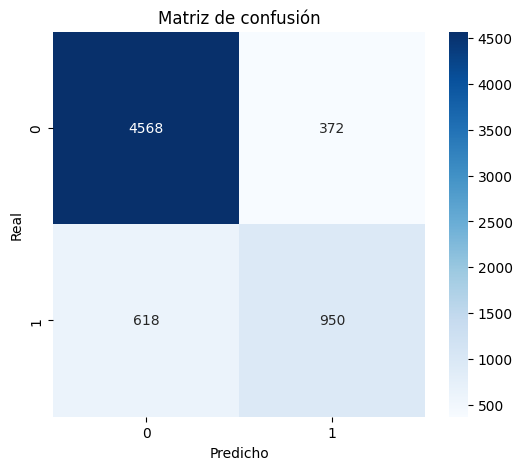

In [37]:
# MATRIZ DE CONFUSIÓN
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

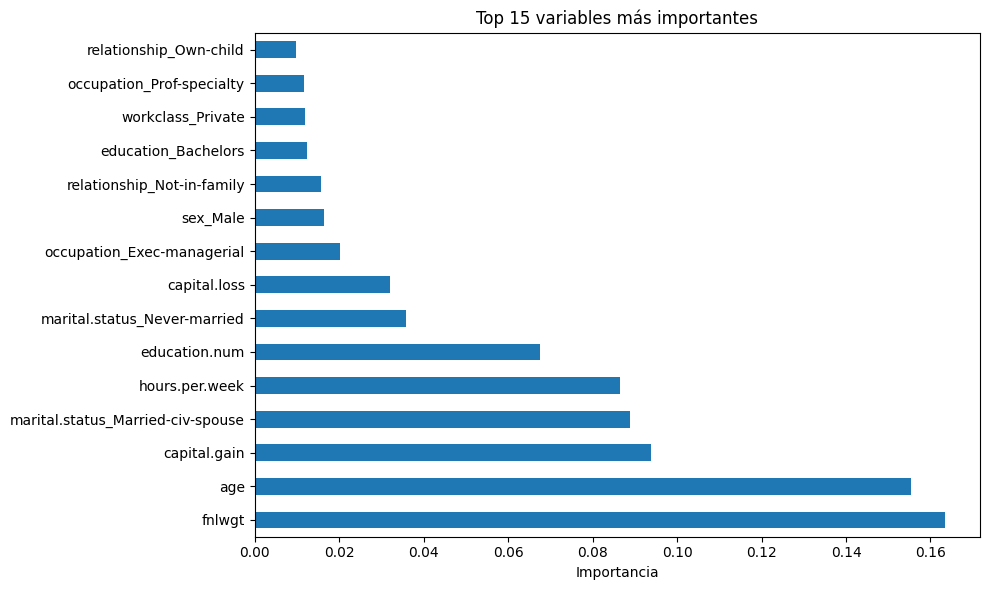

In [38]:
# IMPORTANCIA DE VARIABLES
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X_encoded.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(15).plot(kind='barh')
plt.title('Top 15 variables más importantes')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

### Sistema de recomendación basado en contenido



In [39]:
# Solo usamos personas con income = 1 (éxito)
X_high = X_encoded[y == 1].copy()
X_high['income'] = 1

# Entrenamos KNN sobre perfiles de alto ingreso
nn = NearestNeighbors(n_neighbors=10, metric='euclidean')
nn.fit(X_high.drop('income', axis=1, errors='ignore'))

,n_neighbors,10
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'euclidean'
,p,2
,metric_params,None
,n_jobs,None


In [41]:
# FUNCIÓN DE RECOMENDACION
def recomendar_cambios(perfil_dict, top_n=10):
    # 1. Convertimos el perfil a DataFrame
    perfil = pd.DataFrame([perfil_dict])
    
    # 2. Guardamos valores originales para poder mostrarlos después
    valores_originales = {
        'education': perfil_dict.get('education', '?'),
        'occupation': perfil_dict.get('occupation', '?'),
        'marital.status': perfil_dict.get('marital.status', '?'),
        'workclass': perfil_dict.get('workclass', '?'),
        'hours.per.week': perfil_dict.get('hours.per.week', 0)
    }
    
    # 3. Preprocesamiento exacto igual que en train
    perfil_num = perfil[num_cols]
    perfil_cat = perfil[cat_cols]
    perfil_encoded = pd.get_dummies(perfil_cat, columns=cat_cols, drop_first=True)
    
    # Alineamos columnas con X_encoded
    for col in X_encoded.columns:
        if col not in perfil_encoded.columns:
            perfil_encoded[col] = 0
    perfil_encoded = perfil_encoded[X_encoded.columns]
    
    # Escalamos numéricas
    perfil_encoded[num_cols] = scaler.transform(perfil_num[num_cols])
    
    # 4. Buscamos los vecinos más cercanos entre los que ganan >50K
    distances, indices = nn.kneighbors(perfil_encoded, n_neighbors=top_n)
    vecinos = df.iloc[X_high.index[indices[0]]]  # Recuperamos datos originales
    
    # 5. Probabilidad actual
    prob_actual = rf.predict_proba(perfil_encoded)[0][1]
    
    print(f"Probabilidad actual de ganar >50K: {prob_actual:.1%}\n")
    print(f"Recomendaciones basadas en {top_n} personas similares que SÍ ganan >50K:\n")
    
    # 6. Recomendaciones más frecuentes
    sugerencias = {
        'education': vecinos['education'].mode()[0],
        'occupation': vecinos['occupation'].mode()[0],
        'marital.status': vecinos['marital.status'].mode()[0],
        'workclass': vecinos['workclass'].mode()[0],
        'hours.per.week': int(vecinos['hours.per.week'].median())  # mediana para horas
    }
    
    cambios = []
    for campo, sugerido in sugerencias.items():
        actual = valores_originales[campo]
        if str(actual) != str(sugerido):
            cambios.append(f"• {campo.replace('.', ' ')}: pasar de '{actual}' → '{sugerido}'")
    
    if cambios:
        for c in cambios:
            print(c)
    else:
        print("¡Ya tienes un perfil muy competitivo! Pequeños ajustes podrían bastar.")
    
    return cambios

In [43]:
perfil_1 = {
    'age': 25,
    'workclass': 'Private',
    'fnlwgt': 226000,
    'education': 'HS-grad',
    'education.num': 9,
    'marital.status': 'Never-married',
    'occupation': 'Sales',
    'relationship': 'Own-child',
    'race': 'White',
    'sex': 'Male',
    'capital.gain': 0,
    'capital.loss': 0,
    'hours.per.week': 40,
    'native.country': 'United-States'
}

recomendar_cambios(perfil_1)

Probabilidad actual de ganar >50K: 1.5%

Recomendaciones basadas en 10 personas similares que SÍ ganan >50K:

• occupation: pasar de 'Sales' → 'Adm-clerical'
• marital status: pasar de 'Never-married' → 'Married-civ-spouse'


["• occupation: pasar de 'Sales' → 'Adm-clerical'",
 "• marital status: pasar de 'Never-married' → 'Married-civ-spouse'"]

In [44]:
perfil_2 = {
    'age': 35,
    'workclass': 'Private',
    'fnlwgt': 180000,
    'education': 'Some-college',
    'education.num': 10,
    'marital.status': 'Married-civ-spouse',
    'occupation': 'Adm-clerical',
    'relationship': 'Husband',
    'race': 'White',
    'sex': 'Male',
    'capital.gain': 0,
    'capital.loss': 0,
    'hours.per.week': 35,
    'native.country': 'United-States'
}

recomendar_cambios(perfil_2)

Probabilidad actual de ganar >50K: 2.5%

Recomendaciones basadas en 10 personas similares que SÍ ganan >50K:

• education: pasar de 'Some-college' → 'HS-grad'
• marital status: pasar de 'Married-civ-spouse' → 'Never-married'
• hours per week: pasar de '35' → '40'


["• education: pasar de 'Some-college' → 'HS-grad'",
 "• marital status: pasar de 'Married-civ-spouse' → 'Never-married'",
 "• hours per week: pasar de '35' → '40'"]